PROBABILITY AND STATISTICS PART-2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


PROBABILITY THEORY AND AXIOMS

1A

In [2]:
rolls = np.random.randint(1,7, size=100_000)

p_even=(rolls%2==0).mean()
p_gt4=(rolls>4).mean()
print('P(even) ~', round(p_even, 3), '(true 0.5)')
print('P(>4) ~', round(p_gt4, 3),'(true 0.333)')

P(even) ~ 0.502 (true 0.5)
P(>4) ~ 0.334 (true 0.333)


1B

In [3]:
p1=(rolls==1).mean()
p2=(rolls==2).mean()
p1_or_p2=(np.isin(rolls, [1,2])).mean()
print('P(1)+P(2)=', round(p1+p2, 3))
print('P(1 or 2)=', round(p1_or_p2, 3),'-> they match')

P(1)+P(2)= 0.334
P(1 or 2)= 0.334 -> they match


LAB EXERCISE - 1

In [6]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(p_both_heads, 2), '(true 0.25)')

# 2. P(at least one head)  -> heads >= 1
p_at_least_one = (heads >= 1).mean()
print('P(at least one head) ~', round(p_at_least_one, 2), '(true 0.75)')

# 3. Do P(0) + P(1) + P(2) sum to 1?
p0 = (heads == 0).mean()
p1 = (heads == 1).mean()
p2 = (heads == 2).mean()
total_prob = p0 + p1 + p2
print(f'P(0) + P(1) + P(2) = {p0:.2f} + {p1:.2f} + {p2:.2f} = {total_prob:.2f}')

P(both heads) ~ 0.25 (true 0.25)
P(at least one head) ~ 0.75 (true 0.75)
P(0) + P(1) + P(2) = 0.25 + 0.50 + 0.25 = 1.00


2. CONDITIONAL PROBABILITY AND INDEPENDENCE

2A

In [7]:
rolls = np.random.randint(1, 7, size=(100_000))
even = rolls[rolls%2==0]
p6_given_even = (even==6).mean()
print('P(6 | even) ~', round(p6_given_even, 3), '(true 1/3)')


P(6 | even) ~ 0.331 (true 1/3)


2B

In [8]:
A=rolls>3
B=rolls%2==0
pA=A.mean()
pA_given_B=A[B].mean()
print('P(A) =', round(pA , 3))
print('P(A | B)=', round(pA_given_B, 3))
print('Independent?', np.isclose(pA, pA_given_B, atol=0.02))

P(A) = 0.501
P(A | B)= 0.669
Independent? False


LAB EXERCISE - 2

In [9]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
lt4 = rolls[rolls < 4]
p_odd_given_lt4 = (lt4 % 2 != 0).mean()
print('P(odd | roll < 4) ~', round(p_odd_given_lt4, 3), '(true 2/3 ≈ 0.667)')

# 2. P(roll < 4)
p_lt4 = (rolls < 4).mean()
print('P(roll < 4) ~', round(p_lt4, 3), '(true 0.5)')

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = (rolls % 2 != 0).mean()
is_independent = np.isclose(p_odd_given_lt4, p_odd_overall, atol=0.02)
print('P(odd) overall ~', round(p_odd_overall, 3))
print('Independent?', is_independent)

P(odd | roll < 4) ~ 0.667 (true 2/3 ≈ 0.667)
P(roll < 4) ~ 0.5 (true 0.5)
P(odd) overall ~ 0.499
Independent? False


3. BAYES' THEOREM

3A

In [10]:
p_disease=0.01
p_pos_D=0.99
p_pos_nD=0.01
p_pos=p_pos_D * p_disease + p_pos_nD * (1 - p_disease)
p_D_pos = (p_pos_D * p_disease) / p_pos
print('P(sick | positive test) = ', round(p_D_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) =  0.5
-> only ~50%, because the disease is rare (base-rate effect)


3B

In [11]:
N=1_000_000
has_D=np.random.rand(N)<p_disease
tests_pos=np.where(has_D,
                   np.random.rand(N) < p_pos_D,
                   np.random.rand(N) < p_pos_nD)
among_pos=has_D[tests_pos]
print('Simulated P(sick | positive)=', round(among_pos.mean(),3))

Simulated P(sick | positive)= 0.496


LAB EXERCISE - 3

In [12]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
p_ham = 1.0 - p_spam

# 2. P('free') via total probability
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free') =", round(p_free, 4))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free') =", round(p_spam_given_free, 4))

P('free') = 0.16
P(spam | 'free') = 0.75


4. PROBABILITY DISTRIBUTIONS

4A

In [13]:
bern=stats.bernoulli(p=0.3).rvs(size=10_000)
print("Bernoulli(0.3) mean ~", round(bern.mean(),3),"(true 0.3)")
pois=stats.poisson(mu=4).rvs(size=10_000)
print("Poisson(4) mean ~", round(pois.mean(), 3), "(true 4)")

Bernoulli(0.3) mean ~ 0.294 (true 0.3)
Poisson(4) mean ~ 4.011 (true 4)


4B

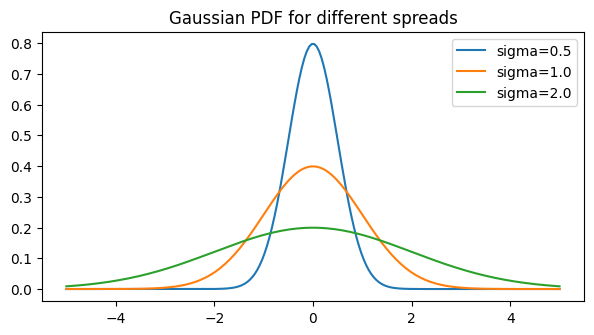

In [14]:
x=np.linspace(-5, 5, 200)
fig, ax=plt.subplots(figsize=(7,3.5))
for sigma in [0.5 , 1.0, 2.0]:
  ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title("Gaussian PDF for different spreads"); ax.legend();
plt.show()

LAB EXERCISE - 4

Poisson(mu=2) sample mean: 2.0068


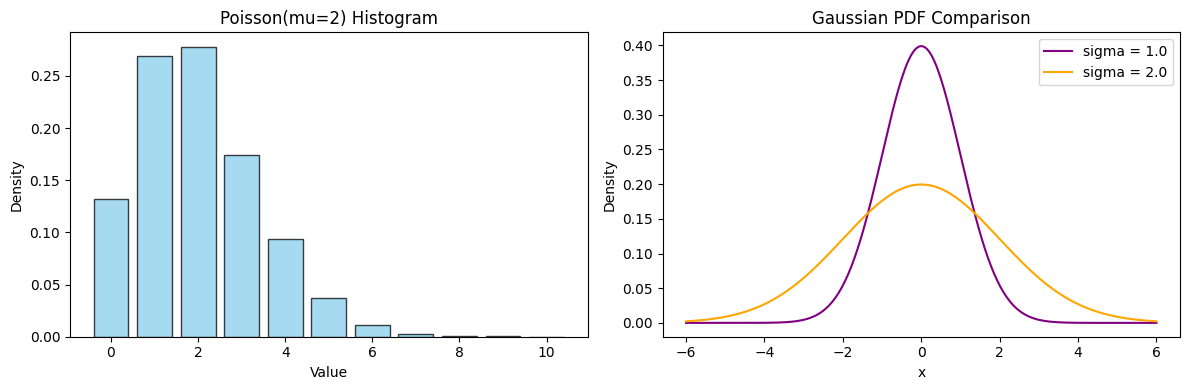

In [15]:
# 1. Poisson(mu=2) samples + mean
poisson_samples = stats.poisson(mu=2).rvs(size=10_000)
print("Poisson(mu=2) sample mean:", poisson_samples.mean())

# 2. histogram of the samples  (plt.hist(...))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(poisson_samples, bins=np.arange(-0.5, poisson_samples.max() + 1.5, 1), rwidth=0.8, density=True, alpha=0.75, color='skyblue', edgecolor='black')
axes[0].set_title("Poisson(mu=2) Histogram")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

# 3. Gaussian PDF for two sigmas on one plot
x_vals = np.linspace(-6, 6, 300)
axes[1].plot(x_vals, stats.norm(0, 1).pdf(x_vals), label="sigma = 1.0", color='purple')
axes[1].plot(x_vals, stats.norm(0, 2).pdf(x_vals), label="sigma = 2.0", color='orange')
axes[1].set_title("Gaussian PDF Comparison")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

5. ENTROPY , KL DIVERGENCE AND MUTUAL INFORMATION

5A

In [16]:
from scipy.stats import entropy
fair = [0.5, 0.5]
biased = [0.9, 0.1]
certain = [1.0, 0.0]

print("entropy fair coin :", round(entropy(fair, base=2),3), 'bits')
print("entropy biased coin :", round(entropy(biased, base=2),3), "bits")
print("Entropy certain:", round(entropy(certain, base=2),3),"bits")

entropy fair coin : 1.0 bits
entropy biased coin : 0.469 bits
Entropy certain: 0.0 bits


5B

In [17]:
p=np.array([0.5, 0.5])
q=np.array([0.9, 0.1])

print("D(p || q) =", round(entropy(p,q, base=2),3), 'bits')
print("D(p || p) =", round(entropy(p, p, base=2), 3),'-> zero (identical)')
print("Note: D(p || q) != D(q || p) ->", round(entropy(q,p,base=2),3),"(not Symmetric)")

D(p || q) = 0.737 bits
D(p || p) = 0.0 -> zero (identical)
Note: D(p || q) != D(q || p) -> 0.531 (not Symmetric)


5C

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris=load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


LAB EXERCISE - 5

In [ ]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)

die4 = [0.25] * 4
die6 = [1/6.0] * 6
ent_4 = entropy(die4, base=2)
ent_6 = entropy(die6, base=2)
print('Entropy of a 4-sided die:', round(ent_4, 3), 'bits')
print('Entropy of a 6-sided die:', round(ent_6, 3), 'bits')

# 2. KL divergence D(P || Q)

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl_div = entropy(P, Q, base=2)
print('KL divergence D(P || Q):', round(kl_div, 3), 'bits')

# 3. Most / least informative iris feature (from 5C)

print('Most informative feature: petal length (cm)')
print('Least informative feature: sepal width (cm)')